In [4]:
import eurostat
import pandas as pd
import numpy as np
import requests, json

%load_ext autoreload
%autoreload 2

DEMOGRAPH = "demo_r_d2jan"
ENVIRONMENT = "env_air_gge"
DBS = [DEMOGRAPH, ENVIRONMENT]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Save full datasets in CSV

In [ ]:
data = eurostat.get_data_df(DEMOGRAPH)
data.to_csv("demo.csv", index=False)
data = eurostat.get_data_df(ENVIRONMENT)
data.to_csv("env.csv", index=False)

# Research dimensions and label meanings

In [ ]:
for DB in DBS:
    print(DB)

    dims = eurostat.get_pars(DB)
    print(f"Dimension labels: {dims}\n")

    for dim in dims:
        print(f"{dim}'s label meanings:\n{eurostat.get_dic(DB, dim)}\n")


In [ ]:
df = eurostat.get_data_df(DEMOGRAPH)
#print(df.columns)

geo_data_demo = sorted(df["geo\\TIME_PERIOD"].unique())
geo_demo_nuts2 = sorted({g for g in geo_data_demo if len(g) == 4 and not g.endswith("ZZ") and not g.endswith("XX") and g not in {"EU28", "EFTA"}})
print(f"Demographic's NUTS2 region labels: {geo_demo_nuts2}")

df = eurostat.get_data_df(ENVIRONMENT)
#print(df.columns)

geo_data_env = sorted(df["geo\\TIME_PERIOD"].unique())
geo_env_country = sorted(set([g for g in geo_data_env if len(g) == 2]))
print(f"Environmental emission country labels: {geo_env_country}")

## Research value_range and staleness

In [ ]:
from datetime import datetime

df = eurostat.get_data_df(DEMOGRAPH)
dim = eurostat.get_pars(DEMOGRAPH)
demo_slice = df[(df["age"] == "TOTAL")
                & (df["sex"] == "T")
                & (df["geo\\TIME_PERIOD"].isin(geo_demo_nuts2))]
demo_vals = demo_slice[demo_slice.columns[len(dim):]]
print(f"Demographic's value range: {demo_vals.min().min()}, {demo_vals.max().max()}")

df_env = eurostat.get_data_df(ENVIRONMENT)
dim_env = eurostat.get_pars(ENVIRONMENT)
AGG = {"EU27_2020", "EU28", "EA19", "EA20"}
env_slice = df_env[(df_env["airpol"] == "GHG")
                   & (df_env["src_crf"] == "TOTX4_MEMO")
                   & (df_env["geo\\TIME_PERIOD"].isin(geo_env_country))]
env_vals = env_slice[env_slice.columns[len(dim_env):]]
print(f"Environmental emission value range: {env_vals.min().min()}, {env_vals.max().max()}")

print(f"Demographic's data staleness: {datetime.now().year - int(demo_slice.columns[len(dim):].max())} year(s)")
print(f"Environmental emission data staleness: {datetime.now().year - int(env_slice.columns[len(dim_env):].max())} year(s)")

Demographic's value range: 0.0, 15907951.0
Environmental emission value range: 1.83974, 1253127.92
Demographic's data staleness: 1 year(s)
Environmental emission data staleness: 2 year(s)


## Fetch JSON format from REST API endpoint

In [ ]:
BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"
resp = requests.get(f"{BASE}/demo_r_d2jan",
    params={"format":"JSON","lang":"en","age":"TOTAL","sex":"T"},
    timeout=30)
resp.raise_for_status()
d = resp.json()
print(json.dumps(d, indent=2))
# print(d["value"])
# print(d["dimension"]["time"]["category"]["index"])

## Convert datasets from JSON-stat into wide format

In [ ]:
# keys = np.array([36])
# np.unravel_index(keys, [1,1,1,1,521,36])
# # -> (array([0,0,0]), ..., array([0,1,468]), array([0,0,0]))
# print(36//521)
# print(521//36)
# print(36%521)
# print(521%36)

resp = requests.get(f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/env_air_gge",
    params={"format":"JSON", "lang":"en"},
    timeout=30)
resp.raise_for_status()
d = resp.json()
print(json.dumps(d, indent=2))

keys = np.array([int(k) for k in d["value"].keys()])
print(keys)
inds = np.unravel_index(keys, d["size"])
print(inds)

cols = {}
for name, ind in zip(d["id"], inds):
    inv = {int(v): k for k, v in d["dimension"][name]["category"]["index"].items()}
    cols[name] = [inv[i] for i in ind]
cols["value"] = [float(v) for v in d["value"].values()]

data = pd.DataFrame(cols)
data.head()

# freq_inv = {int(v): k for k, v in d["dimension"]["freq"]["category"]["index"].items()}
# unit_inv = {int(v): k for k, v in d["dimension"]["unit"]["category"]["index"].items()}
# sex_inv = {int(v): k for k, v in d["dimension"]["sex"]["category"]["index"].items()}
# age_inv = {int(v): k for k, v in d["dimension"]["age"]["category"]["index"].items()}
# geo_inv = {int(v): k for k, v in d["dimension"]["geo"]["category"]["index"].items()}
# time_inv = {int(v): k for k, v in d["dimension"]["time"]["category"]["index"].items()}

## Testing fetch_dataset_json()

In [17]:
from eurostat_dq.ingest import fetch_dataset_json
from eurostat_dq.config import DATASETS

df = fetch_dataset_json("env_air_gge", use_cache=True)
df = fetch_dataset_json("demo_r_d2jan", geo="HU11", sex="T", age="TOTAL")
df.shape
df.head()

DataFrame found in cache
DataFrame acquired from the internet
DataFrame saved to cache


,freq,unit,sex,age,geo,time,value
0,A,NR,T,TOTAL,HU11,2001,1759209.0
1,A,NR,T,TOTAL,HU11,2002,1739569.0
2,A,NR,T,TOTAL,HU11,2003,1719342.0
3,A,NR,T,TOTAL,HU11,2004,1705309.0
4,A,NR,T,TOTAL,HU11,2005,1697343.0


## Cleaning and melting datasets from wide into long format

In [32]:
from eurostat_dq.ingest import fetch_dataset
from eurostat_dq.config import DATASETS
import numpy as np

df = fetch_dataset("demo_r_d2jan", use_cache=True)
df = df.rename(columns={"geo\\TIME_PERIOD":"geo"})

cols = list(df.columns)
base_dims = [dim for dim in cols if not str(dim).isdigit()]

df_long = (df.melt(id_vars=base_dims, var_name="time", value_name="value").dropna(subset=["value"]))
df_long["time"] = df_long["time"].astype(int)

print(df.shape)
print(df.head(20))

df_long.shape
df_long.head()

DataFrame found in cache
['freq', 'unit', 'sex', 'age', 'geo', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
[]
['freq', 'unit', 'sex', 'age', 'geo']
(160800, 41)
   freq unit sex    age   geo       1990       1991       1992       1993  \
0     A   NR   F  TOTAL    AL        NaN        NaN        NaN        NaN   
1     A   NR   F  TOTAL   AL0        NaN        NaN        NaN        NaN   
2     A   NR   F  TOTAL  AL01        NaN        NaN        NaN        NaN   
3     A   NR   F  TOTAL  AL02        NaN        NaN        NaN        NaN   
4     A   NR   F  TOTAL  AL03        NaN        NaN        NaN        NaN   
5     A   NR   F  TOTAL   ALX        NaN        NaN        NaN        NaN   
6     A   NR   F  TOTAL  ALXX        NaN        NaN     

,freq,unit,sex,age,geo,time,value
7,A,NR,F,TOTAL,AT,1990,3989903.0
8,A,NR,F,TOTAL,AT1,1990,1700829.0
9,A,NR,F,TOTAL,AT11,1990,139775.0
10,A,NR,F,TOTAL,AT12,1990,752424.0
11,A,NR,F,TOTAL,AT13,1990,808630.0


## Testing clean.py, ingest.py and schema.py functions

In [6]:
from eurostat_dq.ingest import fetch_dataset, fetch_dataset_json
from eurostat_dq.clean import to_tidy, apply_slice
from eurostat_dq.schema import Record, validate_rows
from eurostat_dq.config import DATASETS

print("FETCH:")
for code, cfg in DATASETS.items():
    raw   = fetch_dataset(code, use_cache=False)
    tidy  = to_tidy(raw)
    clean = apply_slice(tidy, cfg)
    results = validate_rows(clean, cfg)
    print(results[0])
    print(results[1])
    print(results[2])
    # print(code, clean[clean["unit"] != "NR"].head)
    # print("Value range:")
    # print(clean["value"].min())
    # print(clean["value"].max())

# print("FETCH JSON:")
# for code, cfg in DATASETS.items():
#     raw   = fetch_dataset_json(code, use_cache=False)
#     tidy  = to_tidy(raw)
#     clean = apply_slice(tidy, cfg)
#     print(code, clean.head())

FETCH:
DataFrame acquired from the internet
DataFrame saved to cache
[Record(geo='AT11', time=1990, value=270670.0), Record(geo='AT12', time=1990, value=1455968.0), Record(geo='AT13', time=1990, value=1492636.0), Record(geo='AT21', time=1990, value=544983.0), Record(geo='AT22', time=1990, value=1169578.0), Record(geo='AT31', time=1990, value=1296826.0), Record(geo='AT32', time=1990, value=471835.0), Record(geo='AT33', time=1990, value=618459.0), Record(geo='AT34', time=1990, value=323863.0), Record(geo='BE10', time=1990, value=964385.0), Record(geo='BE21', time=1990, value=1597310.0), Record(geo='BE22', time=1990, value=745034.0), Record(geo='BE23', time=1990, value=1331608.0), Record(geo='BE24', time=1990, value=963283.0), Record(geo='BE25', time=1990, value=1102501.0), Record(geo='BE31', time=1990, value=315358.0), Record(geo='BE32', time=1990, value=1278039.0), Record(geo='BE33', time=1990, value=998213.0), Record(geo='BE34', time=1990, value=230827.0), Record(geo='BE35', time=1990,

## Filtering datasets

In [51]:
from eurostat_dq.config import DATASETS, PROJECT_ROOT
from eurostat_dq.ingest import fetch_dataset
from eurostat_dq.clean import to_tidy

df = fetch_dataset(ENVIRONMENT, use_cache=True)
df = to_tidy(df)

filters = DATASETS[ENVIRONMENT].filters
geo_level = DATASETS[ENVIRONMENT].geo_level.lower()

geo_data = sorted(df["geo"].unique())
geo_data_leveled = []

if geo_level == "nuts2":
    geo_data_leveled = sorted({g for g in geo_data if len(g) == 4 and not g.endswith(("ZZ", "XX")) and not g.startswith(("EU", "EA")) and not g.isalpha()})
    print(f"Data of NUTS2 region labels: {geo_data_leveled}")
elif geo_level == "country":
    geo_data_leveled = sorted(set([g for g in geo_data if len(g) == 2]))
    print(f"Data of Country labels: {geo_data_leveled}")

mask = pd.Series(True, index=df.index)
mask &= df["geo"].isin(geo_data_leveled)
for col, val in filters.items():
    mask &= df[col] == val
df = df[mask]
cache_path = PROJECT_ROOT / "data" / "processed" / f"{ENVIRONMENT}.parquet"
cache_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(cache_path, index=False)
df.shape
df.head()

# print("DATA:")
# for i in {"EU27_2020", "EU28", "EA19", "EA20"}:
#     print(i)
#     print(df[df["geo"] == i].head(1))


DataFrame found in cache
Data of Country labels: ['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'TR']


,freq,unit,airpol,src_crf,geo,time,value
16487,A,MIO_T,GHG,TOTX4_MEMO,AT,1990,79.66846
16488,A,MIO_T,GHG,TOTX4_MEMO,BE,1990,145.46665
16489,A,MIO_T,GHG,TOTX4_MEMO,BG,1990,100.19699
16490,A,MIO_T,GHG,TOTX4_MEMO,CH,1990,55.16536
16491,A,MIO_T,GHG,TOTX4_MEMO,CY,1990,5.57948


## Europe statistics

FETCH:
DataFrame found in cache
DataFrame found in cache
<class 'pandas.DataFrame'>
Index: 10320 entries, 107209 to 5735666
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   freq    10320 non-null  str    
 1   unit    10320 non-null  str    
 2   sex     10320 non-null  str    
 3   age     10320 non-null  str    
 4   geo     10320 non-null  str    
 5   time    10320 non-null  int64  
 6   value   10320 non-null  float64
dtypes: float64(1), int64(1), str(5)
memory usage: 782.3 KB
None
               time         value
count  10320.000000  1.032000e+04
mean    2008.528585  1.794311e+06
std       10.146507  1.566778e+06
min     1990.000000  0.000000e+00
25%     2000.000000  8.342722e+05
50%     2009.000000  1.404992e+06
75%     2017.000000  2.222624e+06
max     2025.000000  1.590795e+07
freq     0
unit     0
sex      0
age      0
geo      0
time     0
value    0
dtype: int64
<class 'pandas.DataFrame'>
Index: 1085 entries, 42

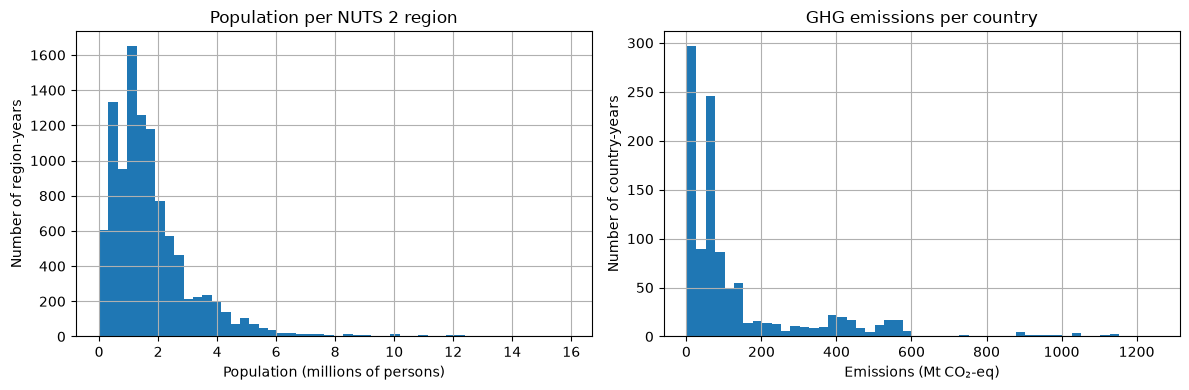

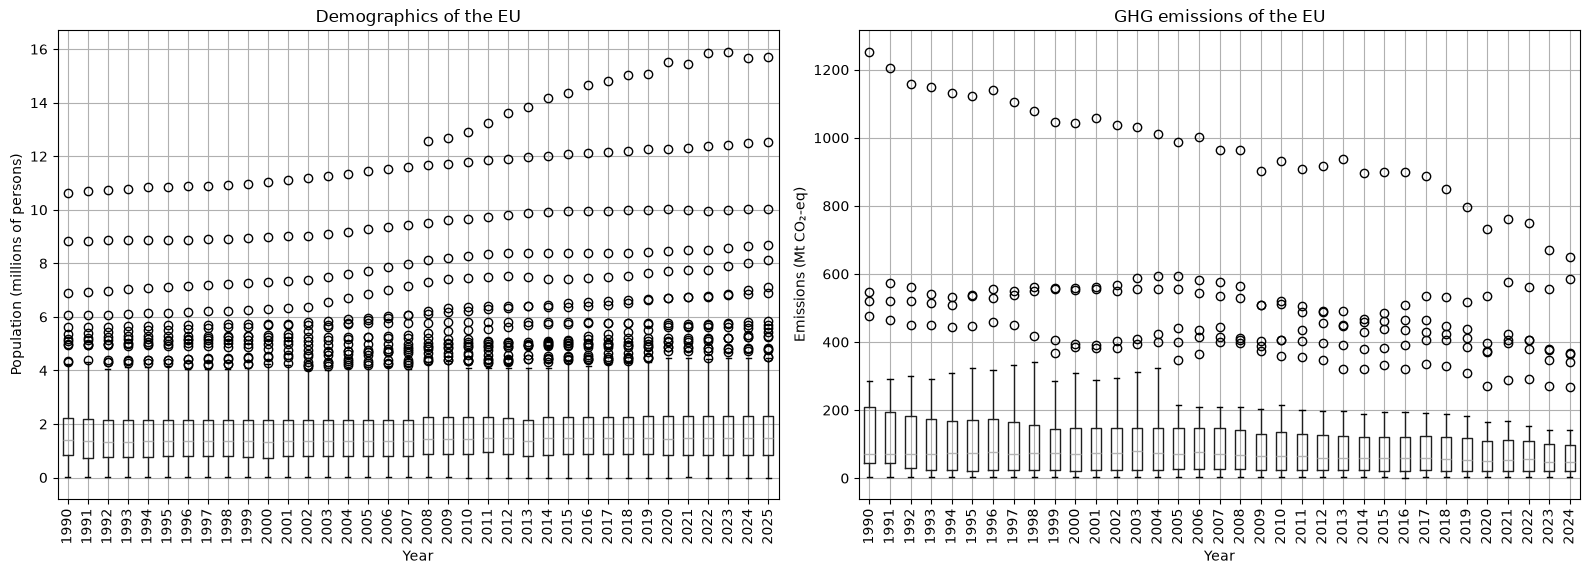

In [ ]:
from eurostat_dq.ingest import fetch_dataset
from eurostat_dq.clean import to_tidy, apply_slice
from eurostat_dq.config import DATASETS
import matplotlib.pyplot as plt

demo = pd.DataFrame()
env = pd.DataFrame()

print("FETCH:")
for code, cfg in DATASETS.items():
    raw   = fetch_dataset(code, use_cache=True)
    tidy  = to_tidy(raw)
    clean = apply_slice(tidy, cfg)
    if cfg.code == "demo_r_d2jan":
        demo = clean
    elif cfg.code == "env_air_gge":
        env = clean

print(demo.info())
print(demo.describe())
print(demo.isnull().sum())
print(env.info())
print(env.describe())
print(env.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(demo["value"] / 1e6).hist(bins=50, ax=axes[0])
axes[0].set_title("Population per NUTS 2 region")
axes[0].set_xlabel("Population (millions of persons)")
axes[0].set_ylabel("Number of region-years")

(env["value"] / 1e3).hist(bins=50, ax=axes[1])
axes[1].set_title("GHG emissions per country")
axes[1].set_xlabel("Emissions (Mt CO₂-eq)")
axes[1].set_ylabel("Number of country-years")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

demo_plot_eu = demo.assign(value=demo["value"] / 1e6)
demo_plot_eu.boxplot(column="value", by="time", ax=axes[0])
axes[0].set_title("Demographics of the EU")
axes[0].set_ylabel("Population (millions of persons)")

env_plot_eu = env.assign(value=env["value"] / 1e3)
env_plot_eu.boxplot(column="value", by="time", ax=axes[1])
axes[1].set_title("GHG emissions of the EU")
axes[1].set_ylabel("Emissions (Mt CO₂-eq)")

for ax in axes:
    ax.set_xlabel("Year")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.suptitle("")
plt.tight_layout()
plt.show()

### Observations:
**Histogram**: Long right tail in both demo and env

**Boxplots**: Bunch of outliers, one high line values in demo and a descending line in env

## Hungarian statistics

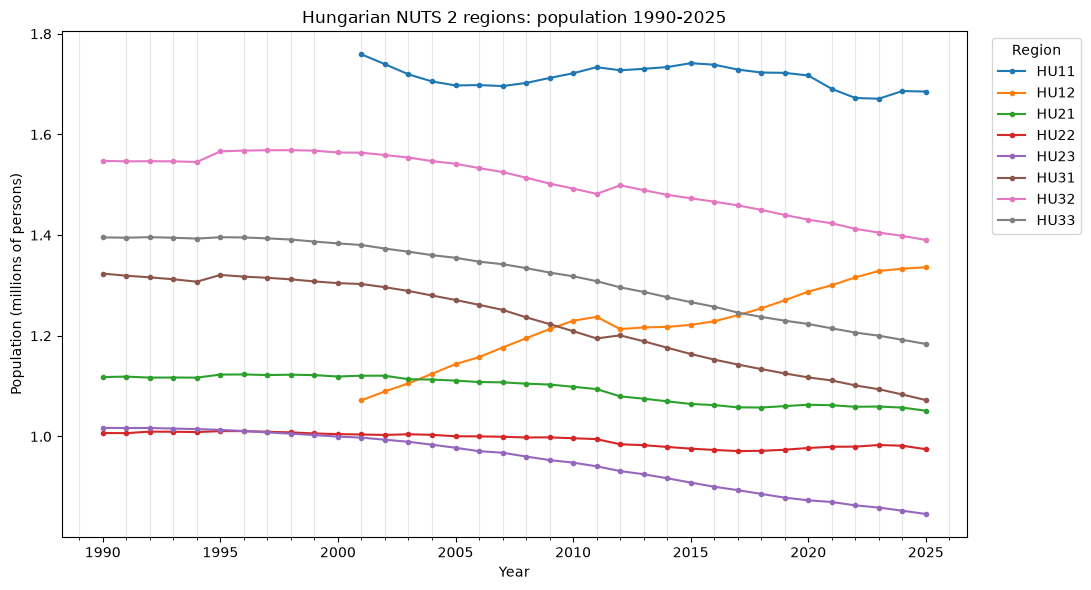

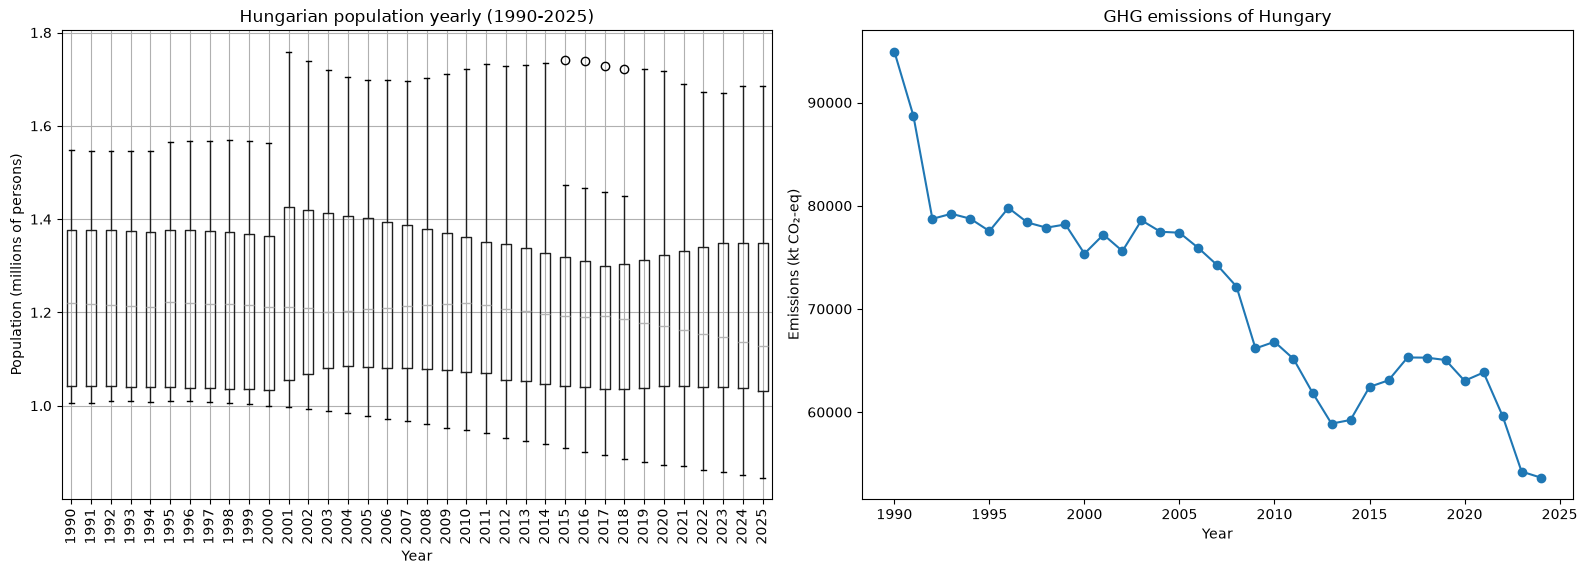

In [59]:
import matplotlib.ticker as ticker

demo = demo[demo.geo.str.startswith("HU")]
env = env[env.geo == "HU"]

# long -> wide: one row per year, one column per region
wide = demo.pivot(index="time", columns="geo", values="value") / 1e6

fig, ax = plt.subplots(figsize=(11, 6))
wide.plot(ax=ax, marker="o", markersize=3)

ax.set_title("Hungarian NUTS 2 regions: population 1990-2025")
ax.set_xlabel("Year")
ax.set_ylabel("Population (millions of persons)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(which="minor", alpha=0.3)
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

demo_plot = demo.assign(value=demo["value"] / 1e6)
demo_plot.boxplot(column="value", by="time", ax=axes[0])
axes[0].set_title("Hungarian population yearly (1990-2025)")
axes[0].set_ylabel("Population (millions of persons)")
axes[0].set_xlabel("Year")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)


e = env.sort_values("time")
axes[1].plot(e["time"], e["value"], marker="o")
axes[1].set_xlabel("Year")
axes[1].set_title("GHG emissions of Hungary")
axes[1].set_ylabel("Emissions (kt CO₂-eq)")

plt.suptitle("")
plt.tight_layout()
plt.show()

### Observations:
**Multi-line**: HU11 (Budaoest) is greater then the others, but decreasing, HU12 (Pest county) is stabely increasing. Both HU11 and HU12 doesn't feature data before 2001 that is not data missing the structure was changed and the first known data is from 2001

**Boxplot**: four outliers 2015-2018 worth inspecting what are they

**Single line**: Shows decreasing tendecy for emmiting GHG